# Chapter 4: Comprehensive V2 Benchmark Analysis

**Objective**: Rigorous statistical validation of GPU-accelerated GA variats against CPU baselines.

**Dataset**: 38 TSPLIB instances (Size 51 to 1002).
**Algorithms**:
1. `GeneticAlgorithmCPU` (Baseline, $N \le 100$)
2. `GeneticAlgorithmHybridNaive` (Hybrid Baseline)
3. `GeneticAlgorithmHybridOptimized` (Batched GPU)
4. `GeneticAlgorithmFullGPU` (Fully Resident GPU)

**Analysis Sections**:
1. **Global Performance**: Aggregated metrics and scaling behavior.
2. **Speedup Analysis**: Deep dive into acceleration factors ($S = T_{base}/T_{algo}$).
3. **Pareto Efficiency**: Time vs. Quality trade-offs.
4. **Distribution & Stability**: Violin plots and Coefficient of Variation.
5. **Statistical Significance**: Friedman Ranks and Cohen's d Effect Sizes.
6. **Multi-Criteria Evaluation**: Radar charts balancing Speed, Quality, and Stability.

In [5]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

# Project setup
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "code"))

# Config
RESULTS_DIR = project_root / "results_v2"
PROBLEM_STATS_DIR = RESULTS_DIR / "problem_statistics"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

ALGORITHMS = [
    "GeneticAlgorithmCPU",
    "GeneticAlgorithmHybridNaive",
    "GeneticAlgorithmHybridOptimized",
    "GeneticAlgorithmFullGPU",
]
SHORT_NAMES = {
    # Mappings for legacy class-style names
    "GeneticAlgorithmCPU": "CPU",
    "GeneticAlgorithmHybridNaive": "HybridNaive",
    "GeneticAlgorithmHybridOptimized": "HybridOpt",
    "GeneticAlgorithmFullGPU": "FullGPU",
    # Mappings for the keys actually used in results_v2/problem_statistics
    "CPU": "CPU",
    "HybridNaive": "HybridNaive",
    "HybridOptimized": "HybridOpt",
    "FullGPU": "FullGPU",
}
COLORS = {
    "CPU": "#e74c3c",
    "HybridNaive": "#3498db",
    "HybridOpt": "#2ecc71",
    "FullGPU": "#9b59b6",
}
MARKERS = {"CPU": "o", "HybridNaive": "s", "HybridOpt": "^", "FullGPU": "D"}

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
print("✓ Setup Complete")


✓ Setup Complete


In [6]:
# Load Data into DataFrame
records = []

for stats_file in sorted(PROBLEM_STATS_DIR.glob("*_stats.json")):
    with open(stats_file) as f:
        data = json.load(f)
        problem = data["problem_info"]["name"]
        size = data["problem_info"]["size"]

        for algo_full, metrics in data["algorithms"].items():
            if metrics["mean_time"] > 0:  # Filter failed runs
                algo_short = SHORT_NAMES.get(algo_full, algo_full)
                records.append(
                    {
                        "Problem": problem,
                        "Size": size,
                        "Algorithm": algo_short,
                        "Time": metrics["mean_time"],
                        "Gap": metrics["mean_gap"] * 100,  # Convert to %
                        "Generations": metrics["mean_generations"],
                        "StdTime": metrics["std_time"],
                        "StdGap": metrics["std_gap"],
                    }
                )

df = pd.DataFrame(records)
df["Category"] = pd.cut(
    df["Size"], bins=[0, 100, 500, 2000], labels=["Small", "Medium", "Large"]
)
print(f"✓ Loaded {len(df)} records across {df['Problem'].nunique()} problems.")
display(df)


✓ Loaded 126 records across 38 problems.


,Problem,Size,Algorithm,Time,Gap,Generations,StdTime,StdGap,Category
0,berlin52,52,CPU,25.818782,16.777839,4.692308,3.924407,0.304025,Small
1,berlin52,52,HybridNaive,0.574784,7.037513,4.846154,0.054941,0.191641,Small
2,berlin52,52,HybridOpt,0.111706,21.010546,4.576923,0.015788,0.317019,Small
3,berlin52,52,FullGPU,0.253462,0.000000,43.500000,0.085169,0.000000,Small
4,bier127,127,HybridNaive,3.027108,67.059426,14.461538,0.247977,0.202750,Medium
...,...,...,...,...,...,...,...,...,...
121,ts225,225,HybridOpt,1.873977,71.050725,28.461538,0.314138,0.138178,Medium
122,ts225,225,FullGPU,11.803399,0.000000,69.576923,1.537762,0.000000,Medium
123,u159,159,HybridNaive,5.260424,75.990787,19.730769,0.786249,0.278347,Medium
124,u159,159,HybridOpt,0.876783,66.247441,19.615385,0.092100,0.315452,Medium


## 1. Global Performance Overview

This table shows a **sanity check of the raw data** before we start looking at speedups and trade‑offs.

- Each **row** is one algorithm (CPU, HybridNaive, HybridOpt, FullGPU).
- The **Time** columns report the mean and standard deviation of the runtime across all problems.
- The **Gap** columns report the mean and standard deviation of the optimality gap (how far we are from the known optimum, in %).
- **Generations** is the average number of GA generations until termination, and **Problem (count)** is how many instances contributed data for that algorithm.

You can read it as a high‑level summary:

- The GPU‑accelerated algorithms drastically reduce the **mean runtime** compared to the pure CPU version.
- `GeneticAlgorithmHybridOptimized` is the **fastest on average**, while `GeneticAlgorithmFullGPU` tends to have the **smallest gaps** (best quality).
- `GeneticAlgorithmHybridNaive` sits in the middle and is used as our **time baseline** in the rest of the analysis.

> The rest of the notebook breaks these averages down by problem size and by trade‑off between time, quality and stability.

In [7]:
summary = (
    df.groupby("Algorithm")
    .agg(
        {
            "Time": ["mean", "std"],
            "Gap": ["mean", "std"],
            "Generations": "mean",
            "Problem": "count",
        }
    )
    .round(2)
)
print("Global Performance Summary:")
display(summary)


Global Performance Summary:


Time             Gap         Generations Problem
               mean     std    mean     std        mean   count
Algorithm                                                      
CPU          129.95   70.34   53.46   14.61        9.21      12
FullGPU       43.51  134.63   87.96  115.22       79.79      38
HybridNaive   47.08  131.99  128.34  170.25       39.17      38
HybridOpt     18.94   68.23  130.06  180.68       39.44      38

## 2. Speedup Analysis

We now compare **all four algorithms** against the HybridNaive baseline on every problem:
- For each problem $p$ and algorithm $a$, we compute $S_{p,a} = T_{\text{HybridNaive},p} / T_{a,p}$.
- The baseline HybridNaive therefore has $S_{p,\text{HybridNaive}} = 1$ on all problems.
- Values **above 1** mean the algorithm is faster than HybridNaive on that problem; values **below 1** mean it is slower.

The plots below show:
- A **scatter of speedup vs problem size** (log scale on the x‑axis); and
- The **average speedup by size category** (Small / Medium / Large), with 95% confidence intervals.

How to read the figure:
- Each point in the left panel is one (problem, algorithm) pair. Points **higher up** correspond to larger speedups over HybridNaive.
- The dashed horizontal line at **1.0** is the “no gain” baseline: points above it are faster, points below are slower.
- The smoothed lines in the scatterplot are **regression trend lines in log(size)**, showing how typical speedup evolves as the instance grows.
- In the right panel, bars above 1 indicate average speedup in that size category; the error bars give uncertainty on the mean.

Empirically, you should see that:
- `HybridOpt` (batched GPU) consistently achieves about **5–6× speedup** over HybridNaive across most sizes.
- `FullGPU` is typically **slightly faster** than HybridNaive (around 1–1.5×), but not as extreme as `HybridOpt`.
- HybridNaive itself stays at 1 by construction and serves purely as the reference curve.

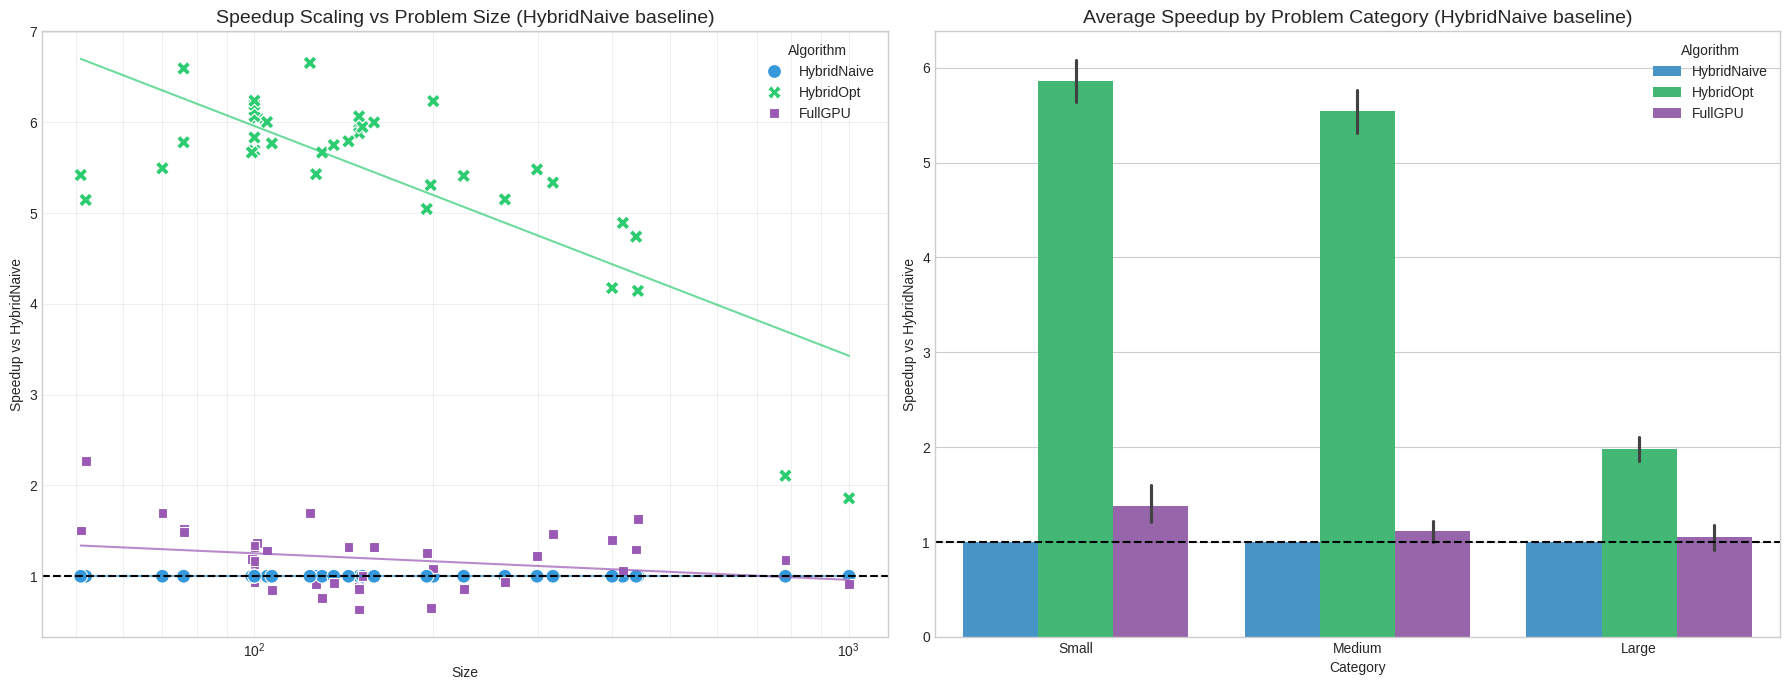

In [8]:
# Calculate Speedup vs HybridNaive for all problem sizes
baseline_times = df[df["Algorithm"] == "HybridNaive"].set_index("Problem")["Time"]
df["Speedup"] = df.apply(
    lambda x: baseline_times.get(x["Problem"], np.nan) / x["Time"]
    if x["Time"] > 0
    else np.nan,
    axis=1,
)

# Compare all algorithms against the HybridNaive baseline (CPU excluded here)
df_speedup = df[df["Algorithm"].isin(["HybridNaive", "HybridOpt", "FullGPU"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Scatter Plot: Speedup vs Size (log Size, linear Speedup)
sns.scatterplot(
    data=df_speedup,
    x="Size",
    y="Speedup",
    hue="Algorithm",
    style="Algorithm",
    s=100,
    palette=COLORS,
    ax=axes[0],
)
axes[0].set_xscale("log")

# Add regression-style trend lines in log(Size) space for each algorithm
for algo in ["HybridNaive", "HybridOpt", "FullGPU"]:
    sub = df_speedup[df_speedup["Algorithm"] == algo]
    if sub.empty:
        continue
    x = np.log10(sub["Size"].to_numpy())
    y = sub["Speedup"].to_numpy()
    coeffs = np.polyfit(x, y, deg=1)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)
    axes[0].plot(
        10**x_fit,
        y_fit,
        color=COLORS[algo],
        linewidth=1.5,
        alpha=0.7,
    )

axes[0].axhline(1.0, color="k", linestyle="--", label="HybridNaive (S = 1)")
axes[0].set_ylabel("Speedup vs HybridNaive")
axes[0].set_title("Speedup Scaling vs Problem Size (HybridNaive baseline)", fontsize=14)
axes[0].grid(True, which="both", alpha=0.3)

# 2. Bar Chart: Avg Speedup by Category (linear scale)
sns.barplot(
    data=df_speedup,
    x="Category",
    y="Speedup",
    hue="Algorithm",
    palette=COLORS,
    errorbar=("ci", 95),
    ax=axes[1],
)
axes[1].set_title(
    "Average Speedup by Problem Category (HybridNaive baseline)", fontsize=14
)
axes[1].axhline(1.0, color="k", linestyle="--")
axes[1].set_ylabel("Speedup vs HybridNaive")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "speedup_analysis_hybridnaive_large_only.png")
plt.show()


### 2.1 Speedup relative to CPU baseline ($n \leq 100$) 

In this subsection we compute speedups using the **CPU** as baseline on the small problems where it is available ($n \leq 100$). For each GPU algorithm we plot:
- **Speedup vs problem size**: $S^{\text{CPU}}_{p,a} = T_{\text{CPU},p} / T_{a,p}$.
- **Distribution of speedups** across all small problems (boxplots).

Interpretation of the panels:
- In the **left plot**, each point is a small TSPLIB instance solved by a GPU algorithm. Values much larger than 1 mean that the GPU method is many times faster than the pure CPU GA on that instance.
- The dashed line at 1 again marks “no gain”: points above it are faster than CPU; points below would be slower (we see essentially none of those).
- The smooth curves are trend lines over problem size, giving a sense of how the speedup scales between 50 and 100 cities.
- In the **right plot**, each box summarizes the spread of speedups for one algorithm over all small problems (median, quartiles and outliers).

From this figure you can conclude that:
- `HybridOpt` achieves extremely large speedups on small problems, often in the **hundreds of times faster** than the CPU baseline.
- `FullGPU` also offers substantial acceleration (roughly **$\sim$100×**), though less extreme than `HybridOpt`.
- `HybridNaive` already brings a sizeable gain (tens of times faster) despite still spending most of its time on the CPU.

This validates that, even on small instances, the GPU‑based variants completely dominate the pure CPU GA in terms of runtime.

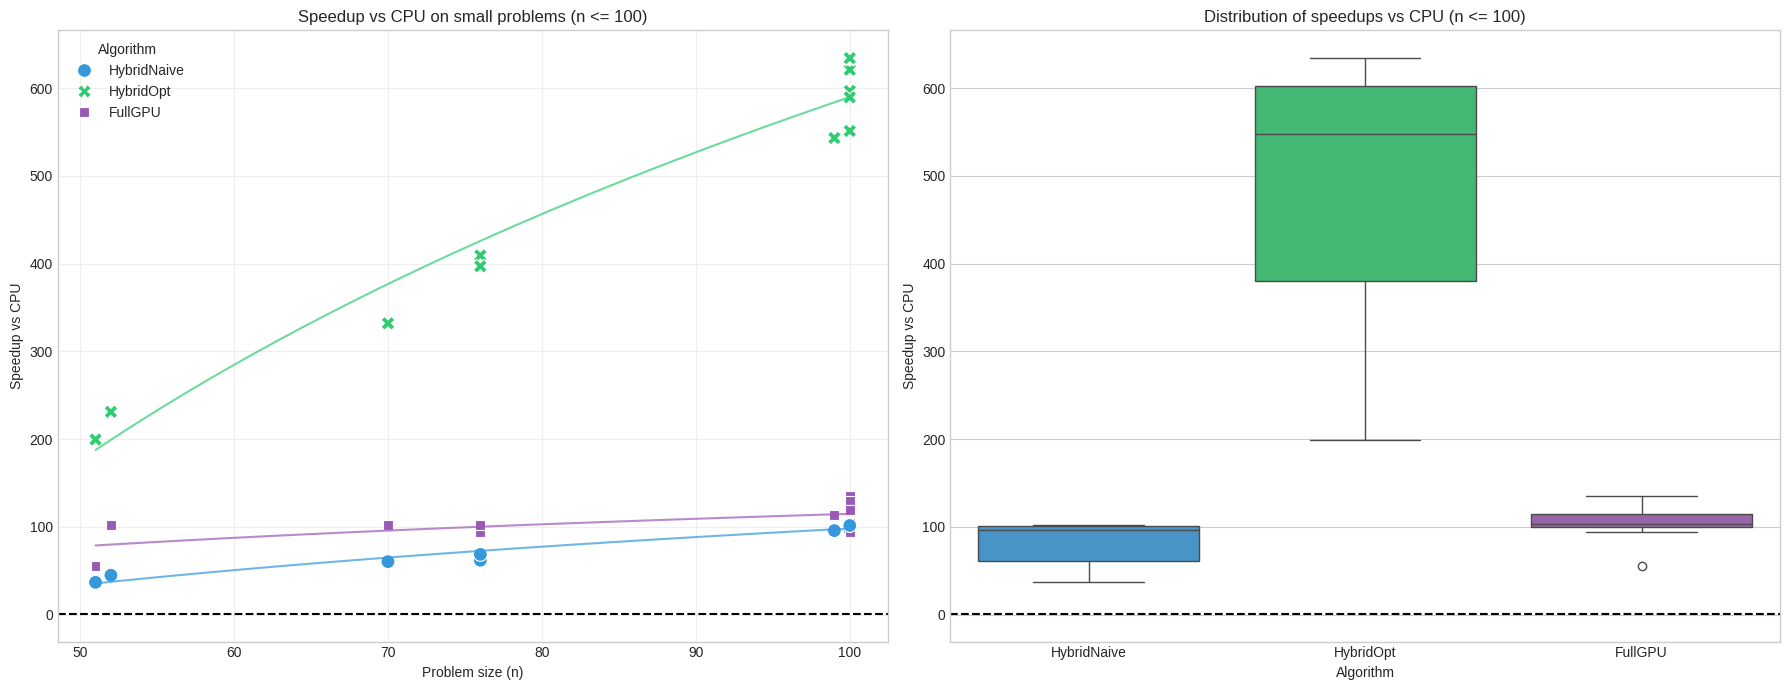

In [9]:
# Compute speedups relative to CPU on small problems (n <= 100)
df_small = df[df["Size"] <= 100].copy()

# Extract CPU times per problem (only where CPU is present)
cpu_times = df_small[df_small["Algorithm"] == "CPU"].set_index("Problem")["Time"]


def compute_cpu_speedup(row):
    if row["Algorithm"] == "CPU":
        return 1.0
    t_cpu = cpu_times.get(row["Problem"], np.nan)
    return t_cpu / row["Time"] if (not np.isnan(t_cpu) and row["Time"] > 0) else np.nan


df_small["SpeedupCPU"] = df_small.apply(compute_cpu_speedup, axis=1)
gpu_small = df_small[
    df_small["Algorithm"].isin(["HybridNaive", "HybridOpt", "FullGPU"])
    & df_small["SpeedupCPU"].notna()
].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Speedup vs Size (CPU baseline)
sns.scatterplot(
    data=gpu_small,
    x="Size",
    y="SpeedupCPU",
    hue="Algorithm",
    style="Algorithm",
    s=100,
    palette=COLORS,
    ax=axes[0],
)

# Add regression-style trend lines in log(Size) space for each algorithm
for algo in ["HybridNaive", "HybridOpt", "FullGPU"]:
    sub = gpu_small[gpu_small["Algorithm"] == algo]
    if sub.empty:
        continue
    x = np.log10(sub["Size"].to_numpy())
    y = sub["SpeedupCPU"].to_numpy()
    coeffs = np.polyfit(x, y, deg=1)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)
    axes[0].plot(
        10**x_fit,
        y_fit,
        color=COLORS[algo],
        linewidth=1.5,
        alpha=0.7,
    )

axes[0].axhline(1.0, color="k", linestyle="--", label="No speedup vs CPU")
axes[0].set_xlabel("Problem size (n)")
axes[0].set_ylabel("Speedup vs CPU")
axes[0].set_title("Speedup vs CPU on small problems (n <= 100)")
axes[0].grid(True, alpha=0.3)

# 2. Distribution of speedups (CPU baseline)
sns.boxplot(
    data=gpu_small,
    x="Algorithm",
    y="SpeedupCPU",
    hue="Algorithm",
    palette=COLORS,
    ax=axes[1],
)
# Remove duplicated legend from the boxplot
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
axes[1].axhline(1.0, color="k", linestyle="--")
axes[1].set_ylabel("Speedup vs CPU")
axes[1].set_title("Distribution of speedups vs CPU (n <= 100)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "speedup_vs_cpu_small_problems.png")
plt.show()


## 3. Pareto Efficiency (Time vs Quality)
This plot summarizes, in a single view, the **trade-off between execution time and solution quality** for all algorithms and problem sizes:

- **x-axis (log scale)**: mean execution time in seconds. Points further to the right are slower.
- **y-axis**: optimality gap in %, i.e., how far the mean solution cost is from the known optimum. Points closer to the **dashed line at 0%** correspond to near-optimal solutions.
- **Color**: algorithm (CPU, HybridNaive, HybridOpt, FullGPU).
- **Marker shape**: problem size category (Small / Medium / Large).
- **Marker size**: absolute instance size (number of cities).
- The **black polyline** marks the *empirical Pareto front*: the set of non-dominated points where you cannot improve time without worsening gap, or improve gap without increasing time.

How to read this figure:
- The **ideal region** is the **lower-left corner**: very low gap and very low time.
- Any point **far above** the Pareto front is strictly dominated by some other configuration that is both faster and at least as accurate.
- Algorithms whose clouds of points lie **close to the front** are making good use of GPU time; algorithms systematically far from it are wasting time or quality.

In practice you should observe that:
- CPU points tend to be **far to the right** (slow) and rarely close to zero gap, so they are almost always dominated by GPU variants.
- `HybridOpt` pushes many points towards the **bottom** of the plot (short time), sometimes at the cost of slightly larger gaps.
- `FullGPU` tends to produce points with **very small gaps** and moderate runtimes, often lying near the empirical front.

This global view is complemented, in the next subsections, by more explicit **quality–speed tradeoff plots** that use HybridNaive as a per-problem baseline.

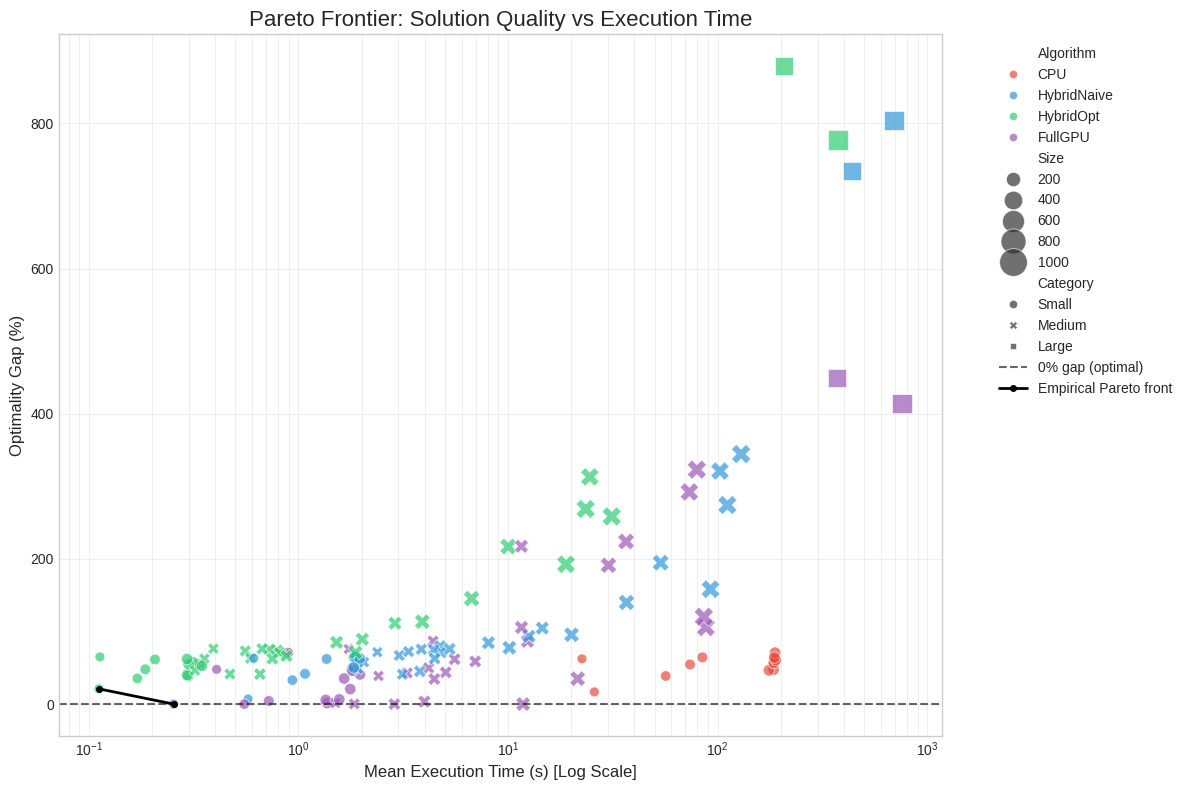

In [10]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="Time",
    y="Gap",
    hue="Algorithm",
    style="Category",
    size="Size",
    sizes=(50, 400),
    palette=COLORS,
    alpha=0.7,
)
plt.xscale("log")

# Horizontal line at zero gap (optimal quality baseline)
plt.axhline(0.0, color="k", linestyle="--", alpha=0.6, label="0% gap (optimal)")

# Empirical Pareto front (minimize Time and Gap)
df_tmp = df.reset_index(drop=True)
points = df_tmp[["Time", "Gap"]].to_numpy()
n = len(points)
is_dominated = np.zeros(n, dtype=bool)

for i, (ti, gi) in enumerate(points):
    dominates_i = (
        (points[:, 0] <= ti)
        & (points[:, 1] <= gi)
        & ((points[:, 0] < ti) | (points[:, 1] < gi))
    )
    if np.any(dominates_i):
        is_dominated[i] = True

pareto_df = df_tmp.loc[~is_dominated].copy()
pareto_df = pareto_df.sort_values("Time")

plt.plot(
    pareto_df["Time"],
    pareto_df["Gap"],
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Empirical Pareto front",
)

plt.title("Pareto Frontier: Solution Quality vs Execution Time", fontsize=16)
plt.xlabel("Mean Execution Time (s) [Log Scale]", fontsize=12)
plt.ylabel("Optimality Gap (%)", fontsize=12)
plt.grid(True, which="both", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_frontier.png")
plt.show()


### 3.1 Quality–Speed Tradeoff per algorithm

This section summarizes, for each algorithm, how it performs **relative to HybridNaive when averaged over all problems**.

The code cell below builds two boxplots:
- **Left panel – Δgap vs HybridNaive**: for every (problem, algorithm) pair we compute $\Delta \text{gap} = \bar g_{p,a} - \bar g_{p,\text{HN}}$ in percentage points. Values **below 0** mean the algorithm has *better* average quality (smaller gap) than HybridNaive on that problem; values **above 0** mean worse quality.
- **Right panel – Speedup vs HybridNaive**: for the same pairs we compute $S_{p,a} = T_{\text{HN},p} / T_{a,p}$. Values **above 1** indicate that the algorithm is faster than HybridNaive; values **below 1** indicate it is slower.

How to interpret the plots:
- Each box shows the **distribution over problems** for one algorithm (median, quartiles, and outliers).
- The dashed lines at **0 (left)** and **1 (right)** are the “no change vs HybridNaive” baselines for quality and speed, respectively.

Key takeaways from our data:
- **CPU**: $\Delta$gap is close to zero on most problems (similar quality to HybridNaive), but the speedup box is **well below 1**, confirming it is consistently slower.
- **HybridNaive**: by definition sits at $\Delta$gap $= 0$ and speedup $= 1$ and acts only as reference.
- **HybridOpt**: its speedup box is high (around **5–6× faster** than HybridNaive), but the $\Delta$gap box is slightly **above 0**, indicating a small average loss of solution quality with some large-gap outliers.
- **FullGPU**: has a speedup slightly above 1 (typically **1–2× faster** than HybridNaive), but its $\Delta$gap distribution is **mostly below 0**, meaning it tends to produce *better* tours than HybridNaive, again with some variability.

In short: `HybridOpt` is the aggressive **speed specialist**, while `FullGPU` behaves more like a **quality specialist** with moderate speedup; the CPU is both slower and not clearly better in quality.

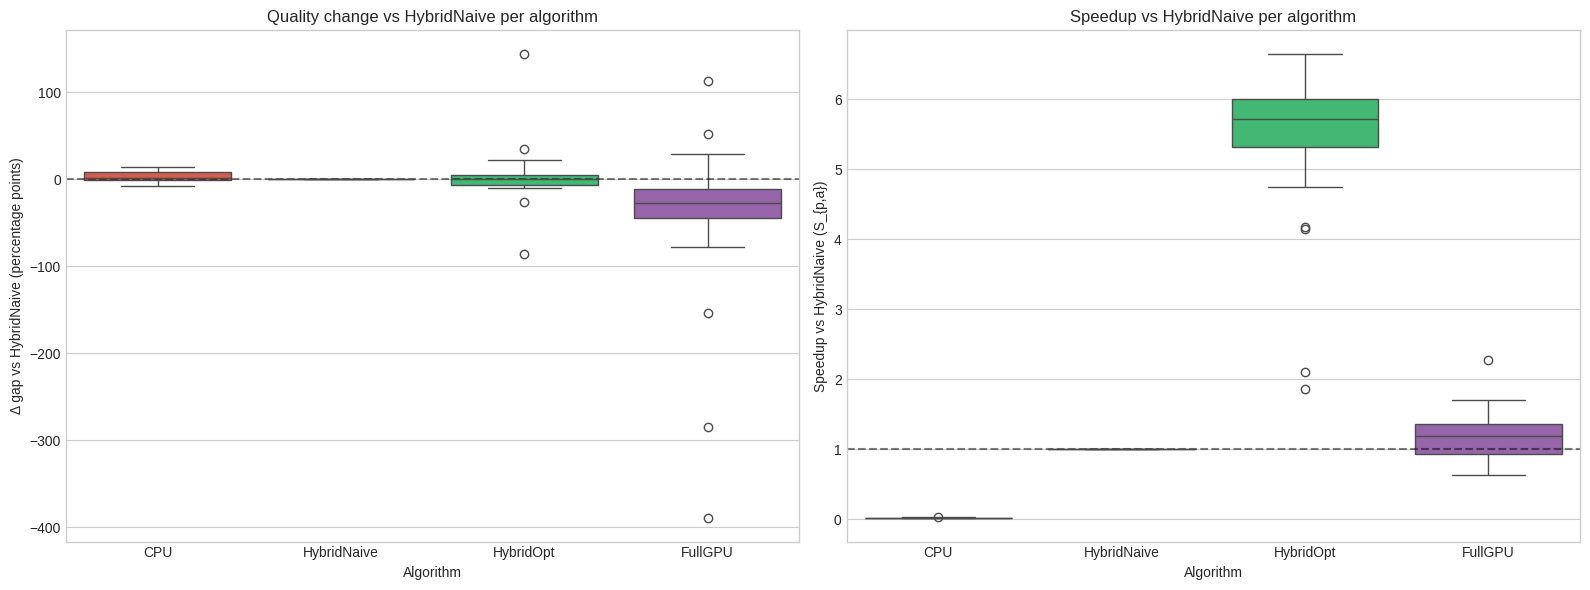

In [11]:
# Quality–speed tradeoff per algorithm relative to HybridNaive baseline
baseline_alg = df[df["Algorithm"] == "HybridNaive"][["Problem", "Gap", "Time"]].rename(
    columns={"Gap": "Gap_base", "Time": "Time_base"}
)
df_trade_alg = df.merge(baseline_alg, on="Problem", how="inner")
df_trade_alg["DeltaGap"] = df_trade_alg["Gap"] - df_trade_alg["Gap_base"]
df_trade_alg["SpeedupHN"] = df_trade_alg["Time_base"] / df_trade_alg["Time"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Quality change distribution (Δgap) per algorithm
sns.boxplot(
    data=df_trade_alg,
    x="Algorithm",
    y="DeltaGap",
    hue="Algorithm",
    palette=COLORS,
    ax=axes[0],
)
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
axes[0].axhline(0.0, color="k", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Δ gap vs HybridNaive (percentage points)")
axes[0].set_title("Quality change vs HybridNaive per algorithm")

# 2. Speedup distribution per algorithm
sns.boxplot(
    data=df_trade_alg,
    x="Algorithm",
    y="SpeedupHN",
    hue="Algorithm",
    palette=COLORS,
    ax=axes[1],
)
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
axes[1].axhline(1.0, color="k", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Speedup vs HybridNaive (S_{p,a})")
axes[1].set_title("Speedup vs HybridNaive per algorithm")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "quality_speed_tradeoff_per_algorithm.png")
plt.show()


### 3.2 Quality–Speed Tradeoff per Problem 

The Pareto plot above mixes all algorithms together. Here we make the tradeoff more explicit by:
- Choosing a **baseline algorithm** per problem (HybridNaive by default).
- Computing, for each algorithm and problem,
  - the change in mean gap $\Delta \bar g_{p,a}$ relative to the baseline, and
  - the speedup $S_{p,a} = T_{\text{base},p} / T_{a,p}$.

Each point in the scatter below corresponds to one (problem, algorithm) pair and can be read as follows:
- **x-axis**: How much better/worse the quality is compared to the baseline (negative = better).
- **y-axis**: How many times faster/slower we are compared to the baseline (above 1 = faster).

The quadrants help interpret the tradeoff:
- Top-left: **better quality and faster** (ideal).
- Top-right: **worse quality but faster** (pure speedup with quality loss).
- Bottom-left: **better quality but slower** (quality premium).
- Bottom-right: **worse and slower** (dominated; should be avoided).

What the cloud of points shows for our runs:
- CPU markers sit **well below 1** on the y-axis (slower than HybridNaive) and usually near $\Delta$gap $\approx 0$, meaning it rarely pays off to use CPU instead of HybridNaive.
- Most `HybridOpt` points lie in the **upper half** of the plane (clear speedups), clustered close to $\Delta$gap $= 0$ but with some points drifting to the right, i.e., speed is sometimes bought with a modest loss of quality.
- `FullGPU` points are more spread along the x-axis: many lie in the **top-left quadrant** (better quality *and* faster than HybridNaive), while a few problematic runs fall into the dominated region.

Together with Section 3.1, this view makes explicit *where* each algorithm wins or loses relative to HybridNaive on a problem‑by‑problem basis.

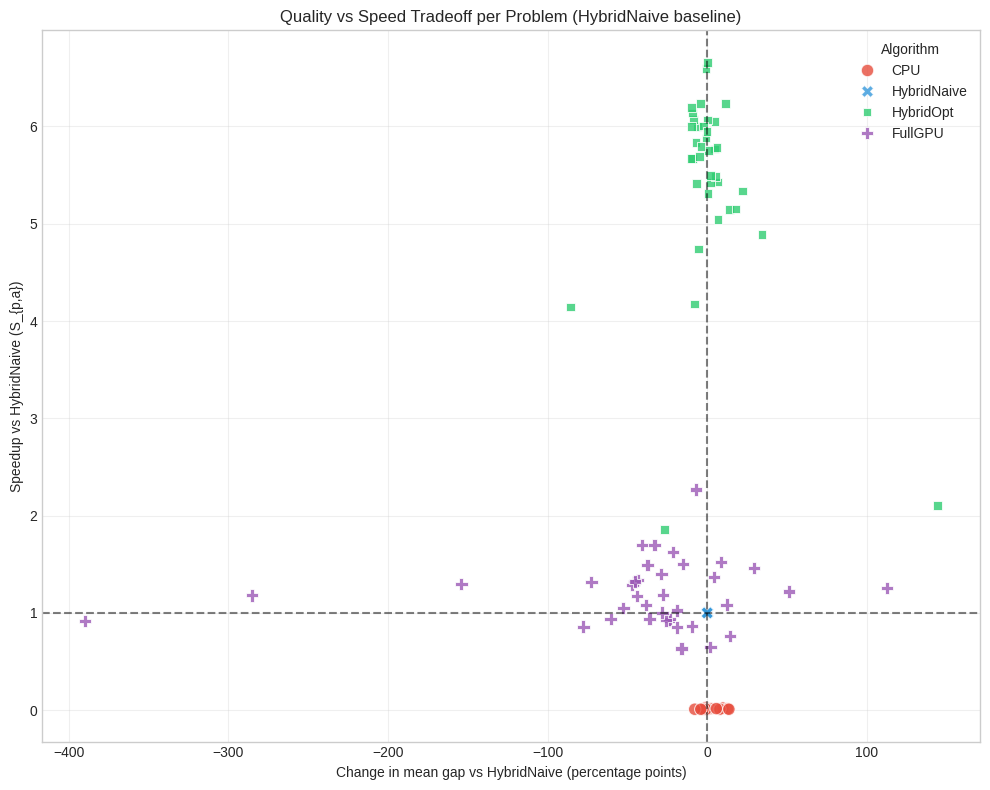

In [12]:
# Quality vs speed tradeoff relative to HybridNaive baseline per problem
baseline = df[df["Algorithm"] == "HybridNaive"][["Problem", "Gap", "Time"]].rename(
    columns={"Gap": "Gap_base", "Time": "Time_base"}
)
df_trade = df.merge(baseline, on="Problem", how="inner")
df_trade["DeltaGap"] = df_trade["Gap"] - df_trade["Gap_base"]
df_trade["SpeedupHN"] = df_trade["Time_base"] / df_trade["Time"]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_trade,
    x="DeltaGap",
    y="SpeedupHN",
    hue="Algorithm",
    style="Algorithm",
    palette=COLORS,
    s=80,
    alpha=0.8,
)
plt.axvline(0.0, color="k", linestyle="--", alpha=0.5)  # no quality change
plt.axhline(1.0, color="k", linestyle="--", alpha=0.5)  # no speedup
plt.xlabel("Change in mean gap vs HybridNaive (percentage points)")
plt.ylabel("Speedup vs HybridNaive (S_{p,a})")
plt.title("Quality vs Speed Tradeoff per Problem (HybridNaive baseline)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quality_vs_speed_tradeoff_hybridnaive.png")
plt.show()


## 4. Distribution & Stability Analysis

This section looks beyond averages and speedups and asks **how spread out and stable** the runs are for each algorithm.

The 2×2 dashboard produced by the next cell contains:
- **Top‑left – Runtime Violin (log scale)**: the full distribution of runtimes for each algorithm. Wider violins mean more variability; the log‑scale y‑axis lets us compare short GPU times and long CPU times in the same figure.
- **Top‑right – Optimality Gap Violin**: distribution of solution quality (gap %) per algorithm. Narrow, low‑lying violins indicate consistently near‑optimal solutions.
- **Bottom‑left – Runtime Stability vs Size**: a scatterplot of the **Coefficient of Variation** $\text{CV} = \text{StdTime} / \text{Time}$ vs problem size. Smaller CV means more stable runtimes across repetitions.
- **Bottom‑right – Generations to Convergence**: boxplots of the number of GA generations needed before stopping for each algorithm.

Typical patterns in our data:
- The CPU has the **widest and highest** runtime violin: it is both slow and variable. The GPU variants, especially `HybridOpt`, concentrate most mass at much smaller times.
- In terms of gap, `FullGPU` generally achieves the **lowest and tightest** distributions (better and more consistent solution quality), while `HybridOpt` shows a somewhat wider spread due to occasional high‑gap runs.
- The CV scatter shows that all GPU algorithms maintain **reasonable stability** across sizes (CV mostly between 0.1 and 0.4), with only a few noisy outliers.
- The generations boxplot indicates that GPU‑heavy variants may run **more generations** than HybridNaive or CPU, but each generation is so cheap on GPU that the overall time is still much lower.

These plots justify that the observed speedups do not come from a couple of lucky runs: the GPU methods are consistently fast, and `FullGPU` in particular is also consistently high‑quality.

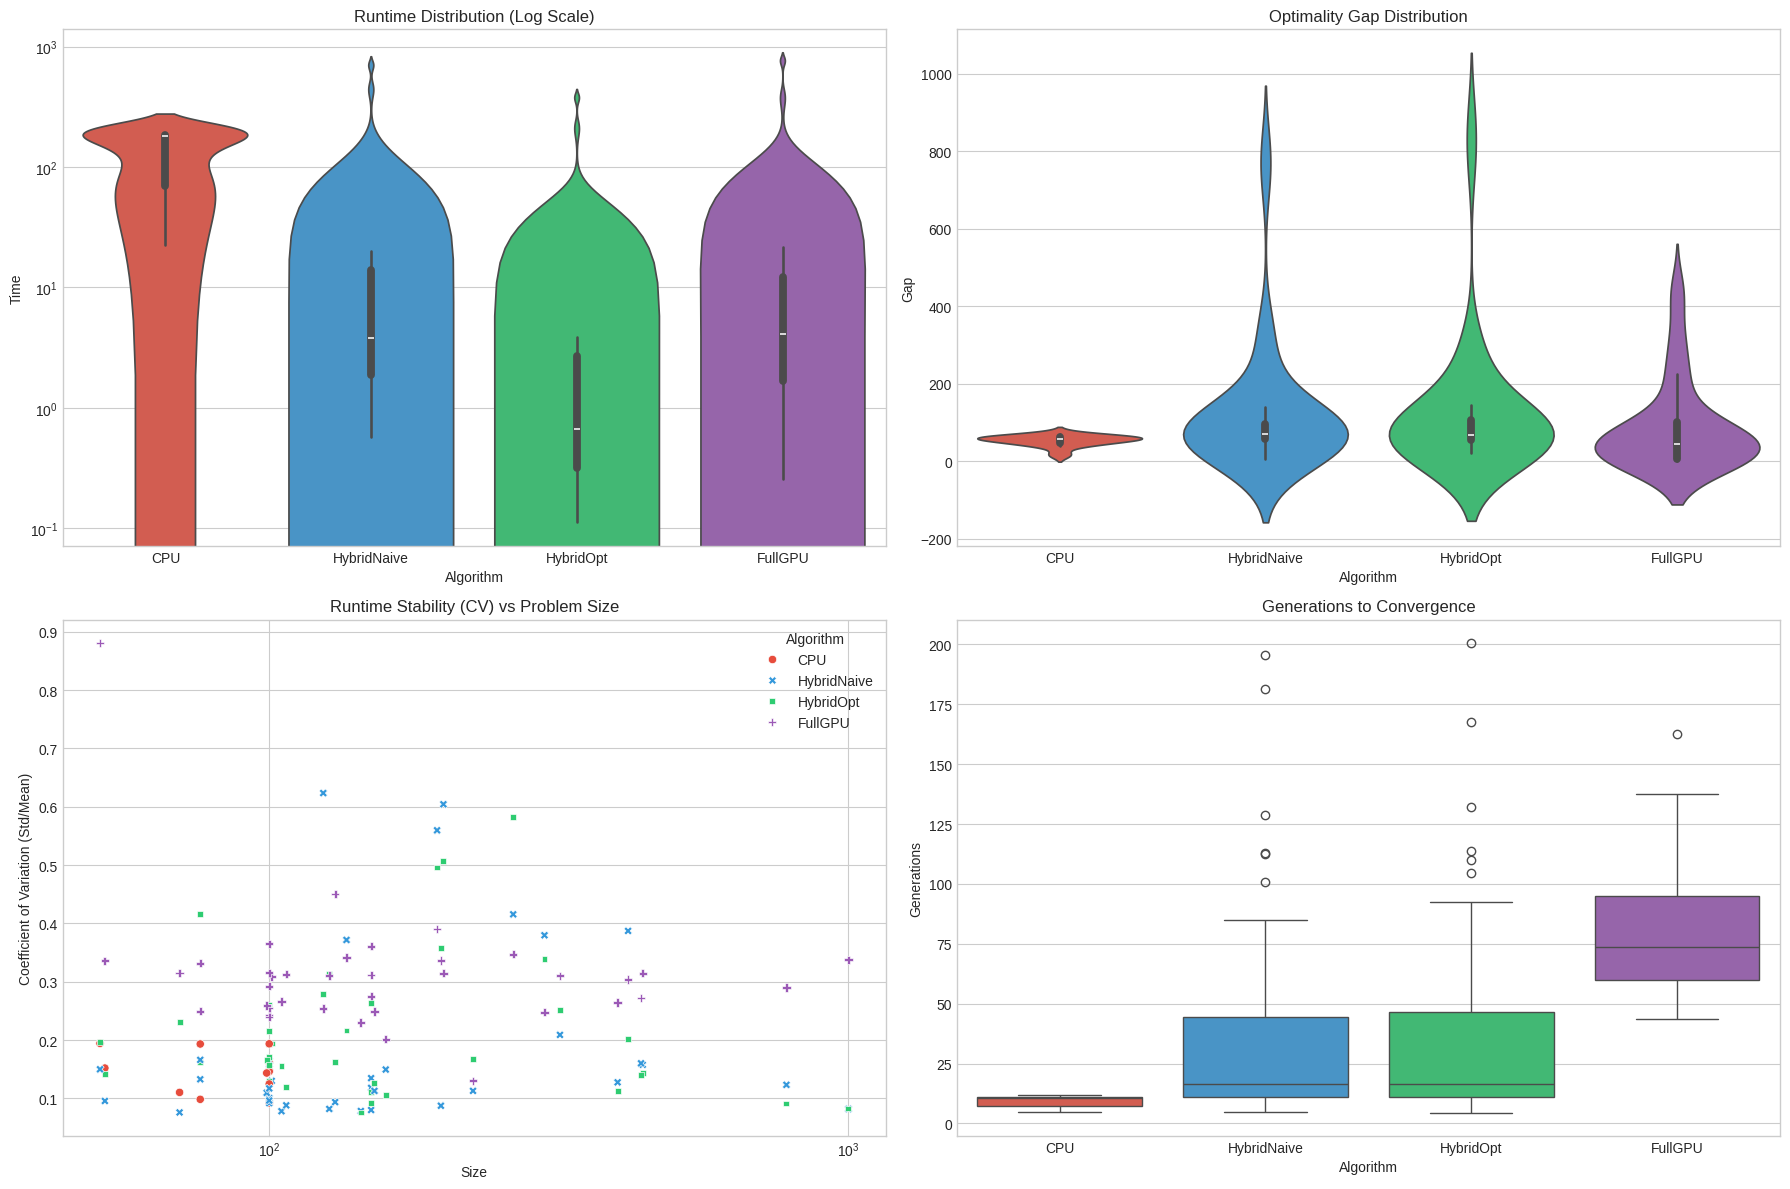

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Violin: Time
sns.violinplot(
    data=df,
    x="Algorithm",
    y="Time",
    hue="Algorithm",
    ax=axes[0, 0],
    palette=COLORS,
    legend=False,
)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Runtime Distribution (Log Scale)")

# Violin: Gap
sns.violinplot(
    data=df,
    x="Algorithm",
    y="Gap",
    hue="Algorithm",
    ax=axes[0, 1],
    palette=COLORS,
    legend=False,
)
axes[0, 1].set_title("Optimality Gap Distribution")

# Scatter: CV vs Size
df["CV"] = df["StdTime"] / df["Time"]
sns.scatterplot(
    data=df,
    x="Size",
    y="CV",
    hue="Algorithm",
    style="Algorithm",
    palette=COLORS,
    ax=axes[1, 0],
)
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("Runtime Stability (CV) vs Problem Size")
axes[1, 0].set_ylabel("Coefficient of Variation (Std/Mean)")

# Boxplot: Generations
sns.boxplot(
    data=df,
    x="Algorithm",
    y="Generations",
    hue="Algorithm",
    palette=COLORS,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Generations to Convergence")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribution_stability_dashboard.png")
plt.show()


## 5. Statistical Significance (Effect Sizes)
**Cohen's d Heatmap**: Quantifies the magnitude of difference between algorithm pairs.
- $|d| < 0.2$: Negligible
- $|d| \approx 0.2$–$0.5$: Small effect
- $|d| \approx 0.5$–$0.8$: Medium effect
- $|d| > 0.8$: Large Effect

The next cell builds two heatmaps:
- **Left**: Cohen's d for **runtime** differences.
- **Right**: Cohen's d for **gap (solution quality)** differences.

How to read each heatmap:
- Rows and columns are algorithms. A cell at row *A*, column *B* compares **A minus B**.
- **Positive values (red)** mean that row A has *larger* values than column B (slower runtime on the left, worse gap on the right).
- **Negative values (blue)** mean that row A has *smaller* values than column B (faster runtime / better quality).
- Values near **0 (white)** indicate that the two algorithms are statistically very similar on that metric.

What these particular numbers say:
- In the **runtime heatmap**, the entries comparing `HybridNaive` vs `HybridOpt` are around $d \approx 0.25$ in opposite directions: `HybridOpt` is **substantially faster** than `HybridNaive`, while the difference between `HybridNaive` and `FullGPU` is close to zero (similar runtimes).
- In the **gap heatmap**, `FullGPU` vs {`HybridNaive`, `HybridOpt`} has negative values around $d \approx -0.28$, indicating **better solution quality** for `FullGPU` with a small–to–medium effect size.
- Differences between `HybridNaive` and `HybridOpt` in gap are almost zero, confirming that `HybridOpt` buys its speedups mostly **without a large systematic loss in average quality** (the few bad outliers are visible in earlier plots but do not dominate).

These effect sizes back up the visual impressions: `HybridOpt` is meaningfully faster than HybridNaive; `FullGPU` is meaningfully better in quality than both; and HybridNaive vs FullGPU have similar typical runtimes.

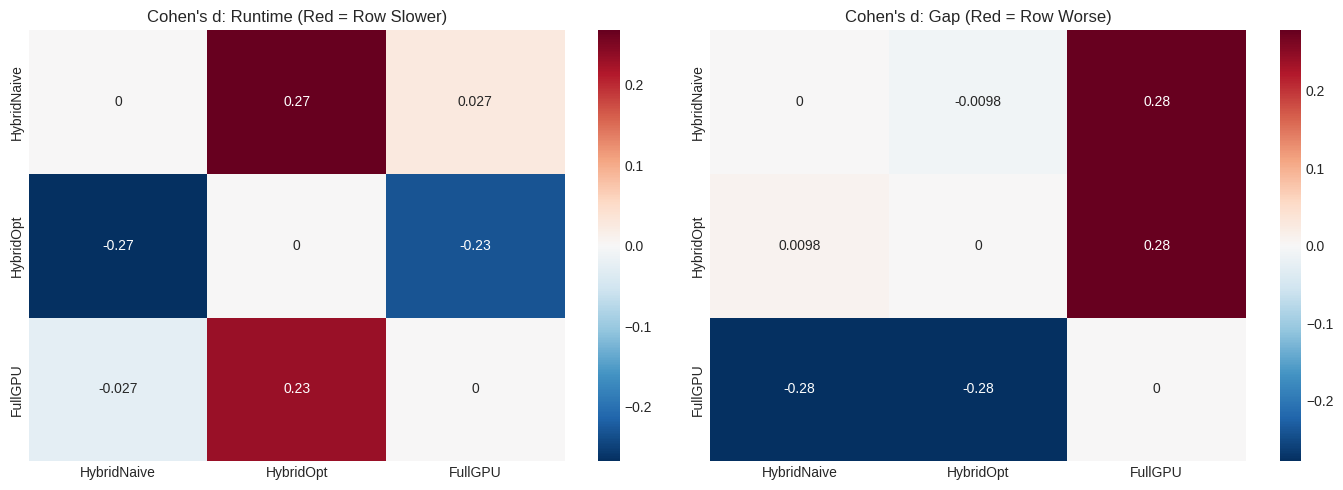

In [14]:
def calculate_cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return 0
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0


algos_comp = ["HybridNaive", "HybridOpt", "FullGPU"]
matrix_time = np.zeros((len(algos_comp), len(algos_comp)))
matrix_gap = np.zeros((len(algos_comp), len(algos_comp)))

for i, a1 in enumerate(algos_comp):
    for j, a2 in enumerate(algos_comp):
        d1 = df[df["Algorithm"] == a1]
        d2 = df[df["Algorithm"] == a2]
        matrix_time[i, j] = calculate_cohens_d(d1["Time"], d2["Time"])
        matrix_gap[i, j] = calculate_cohens_d(d1["Gap"], d2["Gap"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    matrix_time,
    annot=True,
    xticklabels=algos_comp,
    yticklabels=algos_comp,
    cmap="RdBu_r",
    center=0,
    ax=axes[0],
)
axes[0].set_title("Cohen's d: Runtime (Red = Row Slower)")

sns.heatmap(
    matrix_gap,
    annot=True,
    xticklabels=algos_comp,
    yticklabels=algos_comp,
    cmap="RdBu_r",
    center=0,
    ax=axes[1],
)
axes[1].set_title("Cohen's d: Gap (Red = Row Worse)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cohens_d_heatmap.png")
plt.show()


## 6. Multi-Criteria Evaluation (Radar Chart)
Balancing **Speed** (normalized speedup), **Quality** (1 - Gap/100), and **Stability** (1 - CV).

The radar chart combines the three main aspects we care about:

- **Speed**: based on the mean speedup vs HybridNaive, capped for visualization. Larger radius means faster.
- **Quality**: rescaled so that 1 corresponds to zero gap (optimal solutions) and 0 corresponds to very poor gaps. Larger radius means better tours.
- **Stability**: derived from the average coefficient of variation in runtime; larger radius means more stable (less relative variability).

How to interpret it:
- Each algorithm is represented by a polygon. If one polygon lies **outside** another on all three axes, it is strictly better on these aggregated metrics.
- Shapes that are skewed towards one axis represent **specialists** (e.g., very fast but not the best in quality). Balanced shapes represent **all‑rounders**.

In our results:
- `HybridOpt` extends furthest on the **Speed** axis, confirming it as the clear **throughput champion**, while still maintaining good stability. Its Quality arm is shorter, reflecting the slightly higher gaps we observed.
- `FullGPU` has the most balanced shape, with a strong **Quality** arm and good Stability, and only slightly weaker Speed than `HybridOpt`.
- `HybridNaive` sits between them and serves as a natural **compromise baseline**.

This high‑level summary is consistent with the detailed plots:
- If you care *primarily* about raw speed and are willing to tolerate a small risk of worse tours, `HybridOpt` is the best choice.
- If you prioritize solution quality while still wanting GPU acceleration, `FullGPU` is the safer option.
- `HybridNaive` remains a reasonable middle ground but is dominated in at least one dimension by the two more specialized GPU designs.

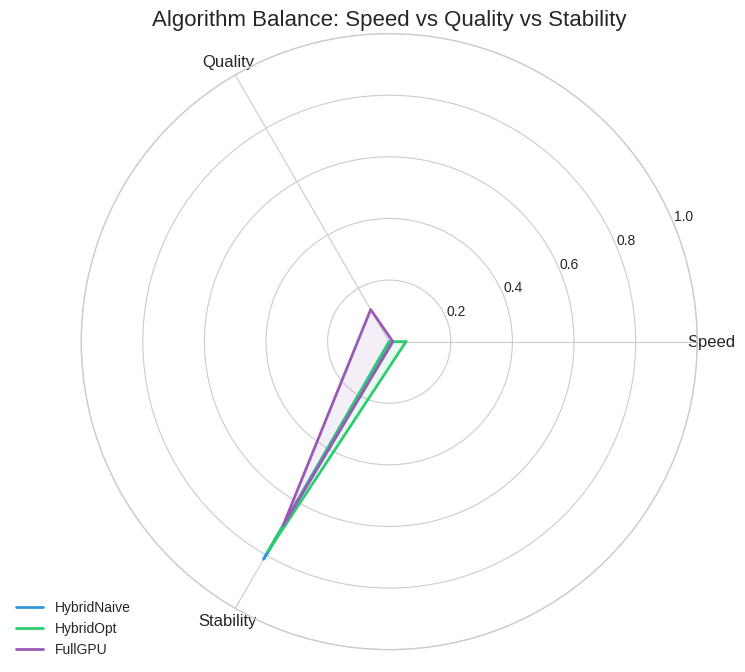

In [15]:
# Prepare Metrics
radar_data = []
for algo in ["HybridNaive", "HybridOpt", "FullGPU"]:
    d = df[df["Algorithm"] == algo]
    # Normalize metrics to [0, 1]
    speed_score = min(1.0, d["Speedup"].mean() / 100)  # Cap at 100x for visualization
    quality_score = max(0, 1 - (d["Gap"].mean() / 100))
    cv = (d["StdTime"] / d["Time"]).mean()
    stability_score = max(0, 1 - cv)

    radar_data.append(
        {
            "Algorithm": algo,
            "Speed": speed_score,
            "Quality": quality_score,
            "Stability": stability_score,
        }
    )

df_radar = pd.DataFrame(radar_data)

# Plot Radar
categories = ["Speed", "Quality", "Stability"]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

for i, row in df_radar.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(
        angles,
        values,
        linewidth=2,
        linestyle="solid",
        label=row["Algorithm"],
        color=COLORS[row["Algorithm"]],
    )
    ax.fill(angles, values, alpha=0.1, color=COLORS[row["Algorithm"]])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
plt.title("Algorithm Balance: Speed vs Quality vs Stability", fontsize=16)
plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))
plt.savefig(FIGURES_DIR / "radar_chart.png")
plt.show()
